# Heart Disease UCI Dataset — Exploratory Data Analysis

MLOps Assignment 01 (AIMLCZG523) — Task 1: Data Acquisition & EDA

This notebook downloads the UCI Heart Disease (Cleveland) dataset, cleans it, binarizes the target, and produces the required visualizations: histograms, correlation heatmap, class balance, and missing value analysis.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_raw, clean_and_binarize, NUMERIC_FEATURES, BINARY_TARGET_COLUMN

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load raw data

In [2]:
RAW_PATH = '../data/raw/heart_disease_uci_raw.csv'
raw = load_raw(RAW_PATH)
raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6   restecg    303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         299 non-null    float64
 12  thal       301 non-null    float64
 13  diagnosis  303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## 2. Missing value analysis

The UCI Cleveland file encodes missing values with `?` in the `ca` and `thal` columns.

In [4]:
missing_markers = (raw.astype(str) == '?').sum()
missing_markers[missing_markers > 0]

Series([], dtype: int64)

## 3. Clean & binarize target

The raw `diagnosis` column is 0 (no disease) through 4 (severity levels 1-4). Per the assignment's binary-target requirement, we collapse this to 0 = no disease, 1 = disease present.

In [5]:
df = clean_and_binarize(raw)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## 4. Class balance

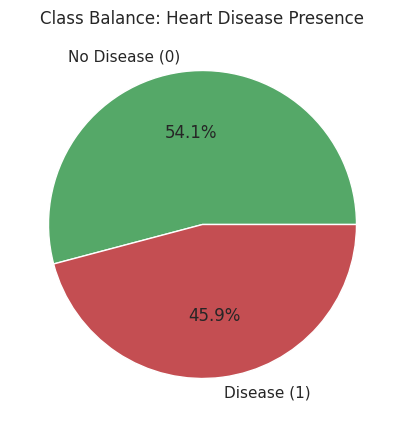

target
0    164
1    139
Name: count, dtype: int64

In [7]:
counts = df[BINARY_TARGET_COLUMN].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['#55A868', '#C44E52'])
plt.title('Class Balance: Heart Disease Presence')
plt.show()
counts

The dataset is *reasonably* balanced (roughly 54% / 46%), so accuracy alone is a meaningful metric here, but we still track precision/recall/ROC-AUC in modelling since false negatives (missed disease) are the costlier error clinically.

## 5. Histograms of numeric features

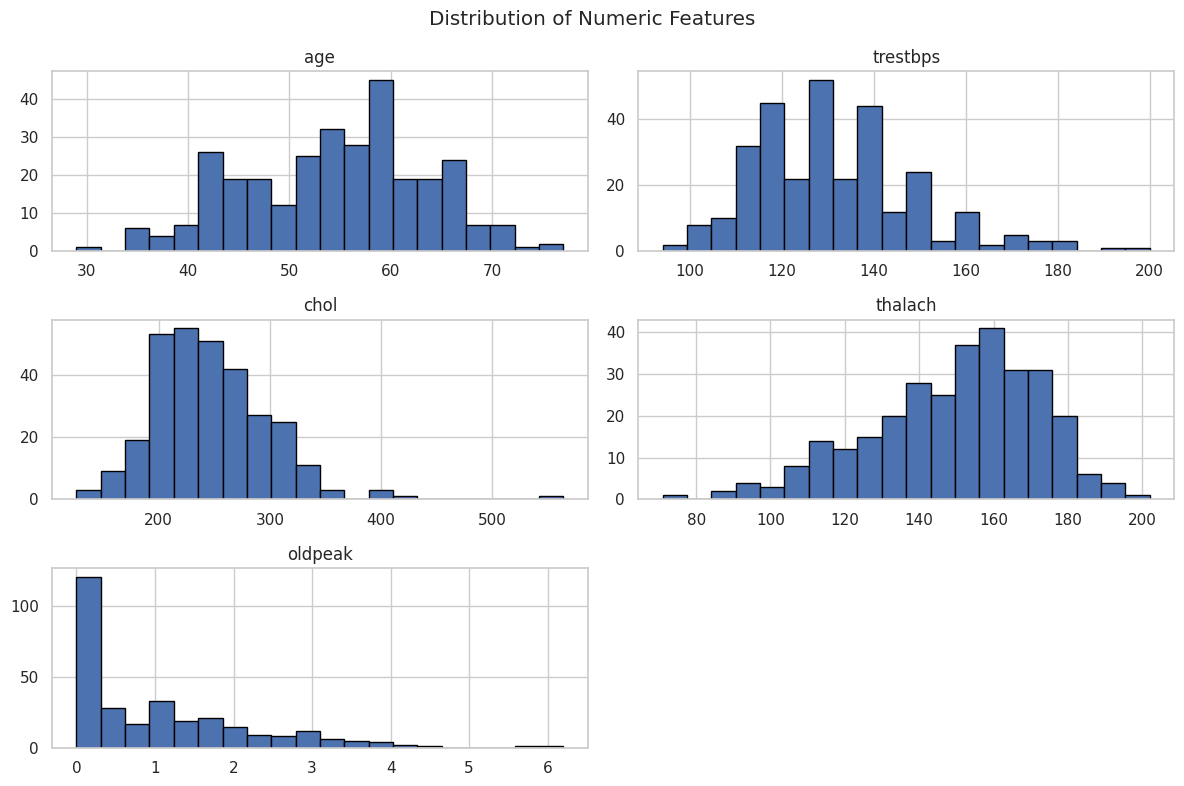

In [8]:
df[NUMERIC_FEATURES].hist(figsize=(12, 8), bins=20, color='#4C72B0', edgecolor='black')
plt.suptitle('Distribution of Numeric Features')
plt.tight_layout()
plt.show()

## 6. Correlation heatmap

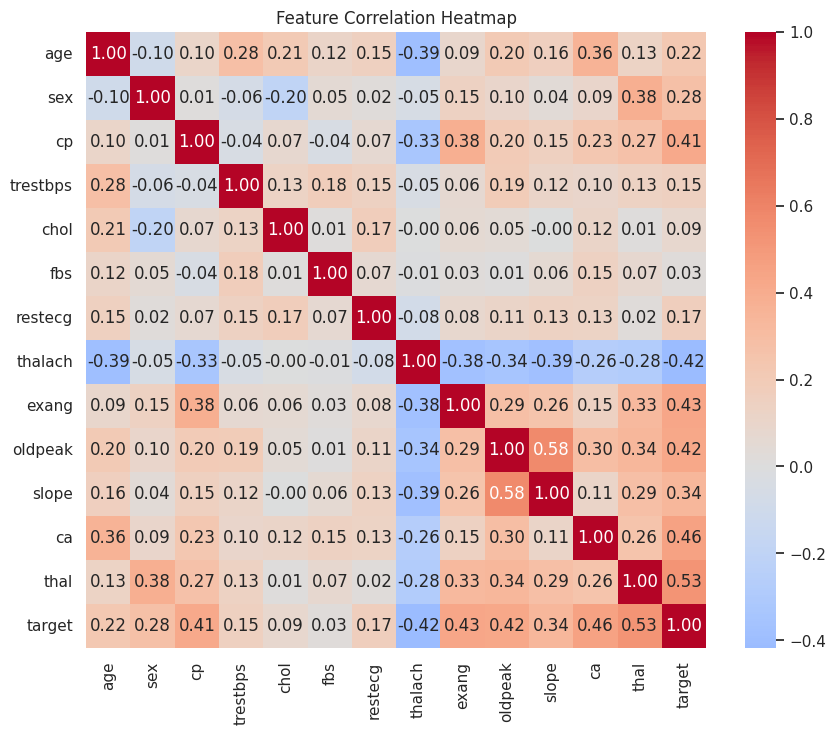

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

**Observations:** `thal`, `ca`, `oldpeak`, `cp`, and `exang` show the strongest correlation with the target — consistent with clinical literature (ST depression, number of major vessels, and chest pain type are established heart-disease risk indicators).

## 7. Feature relationship: Age vs Max Heart Rate

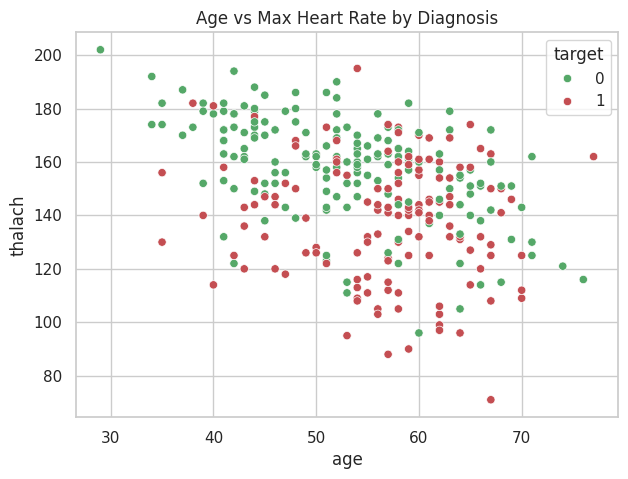

In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='age', y='thalach', hue=BINARY_TARGET_COLUMN, palette=['#55A868', '#C44E52'])
plt.title('Age vs Max Heart Rate by Diagnosis')
plt.show()

Patients with disease tend to cluster at lower maximum heart rates for a given age, matching the negative correlation seen in the heatmap above.

## Summary of EDA findings
- 303 patient records, 13 features + binary target
- 6 rows have missing values in `ca` (4) and `thal` (2) — handled via median/most-frequent imputation in the pipeline
- Target is moderately balanced (~54% no disease / ~46% disease)
- Strongest predictors: `thal`, `ca`, `oldpeak`, `cp`, `exang`, `thalach`
- No extreme outliers requiring removal; StandardScaler handles the numeric feature scale differences